# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cuml.manifold import UMAP

import seaborn as sns
from pyprojroot.here import here
import lightgbm as lgb
import shap
import yaml
import itertools

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys
import importlib


# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent.parent


# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria
from funciones.graficos_clusters_pdf  import generar_pdf_clusters
from funciones.distribucion_clusters_pdf  import generar_pdf_distribuciones_clusters
from funciones.consolidar_clientes  import construir_dataset_por_cliente, agregar_delta_lags, agregar_mes_baja

# URLs y Constantes

In [3]:
ROOT_URL = here()
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')
DATA_URL = os.path.join(DATA_FOLDER, 'competencia_01_crudo.csv')
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_DICT_URL= os.path.join(DATA_FOLDER, 'data_dict.csv')

CODE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

EXP_URL = os.path.join(CODE_URL, 'DATA', 'EXP')

SEED = 230047

In [4]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_ternaria_lags.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# UTILS

In [5]:

def evaluar_umap_kmeans(
    X_shap,
    N_COMPONENTS,
    N_NEIGHBORS,
    MIN_DIST,
    METRICS,
    N_CLUSTERS,
    N_SEEDS,
    SAMPLE_FRAC,
    SEED,
):
    rng = np.random.default_rng(SEED)

    sample_idx = rng.choice(
        len(X_shap),
        size=int(len(X_shap) * SAMPLE_FRAC),
        replace=False,
    )

    X_sample = X_shap[sample_idx].astype(
        np.float32,
        copy=False,
    )

    resultados_umap = []

    combinaciones = itertools.product(
        N_COMPONENTS,
        N_NEIGHBORS,
        MIN_DIST,
        METRICS,
        N_CLUSTERS,
    )

    for (
        n_components,
        n_neighbors,
        min_dist,
        metric,
        n_clusters,
    ) in combinaciones:

        metricas = {
            "sil": [],
            "db": [],
            "ch": [],
        }

        clusters_semillas = []

        for seed in range(SEED, SEED + N_SEEDS):

            reducer = UMAP(
                n_components=n_components,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                metric=metric,
                build_algo="nn_descent",
                output_type="numpy",
                random_state=seed,
            )

            embedding = reducer.fit_transform(X_sample)

            labels_cluster = KMeans(
                n_clusters=n_clusters,
                random_state=seed,
            ).fit_predict(embedding)

            clusters_semillas.append(labels_cluster)

            metricas["sil"].append(
                silhouette_score(
                    embedding,
                    labels_cluster,
                    sample_size=20_000,
                    random_state=seed,
                )
            )

            metricas["db"].append(
                davies_bouldin_score(
                    embedding,
                    labels_cluster,
                )
            )

            metricas["ch"].append(
                calinski_harabasz_score(
                    embedding,
                    labels_cluster,
                )
            )

        ari = []
        nmi = []
        vdn = []

        pares_semillas = itertools.combinations(
            clusters_semillas,
            2,
        )

        for labels_a, labels_b in pares_semillas:

            ari.append(
                adjusted_rand_score(
                    labels_a,
                    labels_b,
                )
            )

            nmi.append(
                normalized_mutual_info_score(
                    labels_a,
                    labels_b,
                )
            )

            contingency = pd.crosstab(
                pd.Series(
                    labels_a,
                    name="cluster_a",
                ),
                pd.Series(
                    labels_b,
                    name="cluster_b",
                ),
            )

            vdn.append(
                van_dongen_normalized(contingency)
            )

        resultados_umap.append({
            "n_clusters": n_clusters,
            "n_components": n_components,
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "metric": metric,
            "sil": np.mean(metricas["sil"]),
            "db": np.mean(metricas["db"]),
            "ch": np.mean(metricas["ch"]),
            "ari_estabilidad": np.mean(ari),
            "nmi_estabilidad": np.mean(nmi),
            "vdn_estabilidad": np.mean(vdn),
            "s_sil": np.std(metricas["sil"]),
            "s_db": np.std(metricas["db"]),
            "s_ch": np.std(metricas["ch"]),
            "s_ari": np.std(ari),
            "s_nmi": np.std(nmi),
            "s_vdn": np.std(vdn),
        })

    return pd.DataFrame(resultados_umap)

In [6]:
def van_dongen_normalized(contingency):
    n = contingency.values.sum()
    sum_max_rows = contingency.max(axis=1).sum()  # para cada label, max sobre clusters
    sum_max_cols = contingency.max(axis=0).sum()  # para cada cluster, max sobre labels
    max_row_total = contingency.sum(axis=1).max()
    max_col_total = contingency.sum(axis=0).max()
    
    vdn = (2*n - sum_max_rows - sum_max_cols) / (2*n - max_row_total - max_col_total)
    return vdn

# LEEMOS DATOS

In [7]:
df = pd.read_csv(
    DATA_TERNARIA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

/tmp/ipykernel_374642/3175415450.py:1: DtypeWarning: Columns (0: ternaria) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## Agregamos MES_BAJA 

In [8]:
df = agregar_mes_baja(df)

In [9]:
# La diferencia esta en que mes_baja existe para cada registro de un cliente q se dio de baja
# a diferencia de ternaria q existe solo para los registors q estan a 1 o 2 meses de esa baja. 
df.mes_baja.value_counts(dropna = False), df.ternaria.value_counts(dropna=False)

(mes_baja
 <NA>      967801
 202108      5481
 202107      3459
 202106      3401
 202105      1906
 202104      1013
 Name: count, dtype: Int64,
 ternaria
 continua    645999
 NaN         327892
 BAJA+1        5103
 BAJA+2        4067
 Name: count, dtype: int64)

# ANALISIS

## Nos movemos de  cliente/mes a  cliente 
    creemos una sola fila por cliente, usando mes actual como linea y desplazando al pasado los demas valores.

## Columnas mas importantes en lightgbm segun experimento HT4942


In [10]:
exp_referencia = 'HT4942'
var_imp_url = os.path.join(ROOT_URL, 'DATA', 'EXP', exp_referencia, 'impo.txt')
var_imp = pd.read_csv(var_imp_url, sep=r"\s+")  #leemos como csv y usamos espacio como separador
var_imp =  var_imp.sort_values(by='Gain', ascending=False)

In [11]:
keep_features = var_imp[:50]['Feature'].to_list()
keep_features_extended =keep_features.copy()
keep_features_extended.append('ternaria')
keep_features_extended.append('foto_mes')
keep_features_extended.append('mes_baja')



In [12]:
# pd.Series(keep_features)[pd.Series(keep_features).str.contains('anti')]

## Filtramos dataset para dejar solo estas columnas

In [13]:
df_filtrado = df[keep_features_extended].copy()
df_filtrado.loc[df_filtrado['mes_baja'].notna()]

,ctrx_quarter,mcaja_ahorro,mprestamos_personales,mpayroll,mcuentas_saldo,mpasivos_margen,cpayroll_trx,mtarjeta_visa_consumo,mrentabilidad_annual,mcuenta_corriente,...,ctarjeta_debito_transacciones,ccomisiones_otras,mcomisiones_otras,mttarjeta_visa_debitos_automaticos,mtransferencias_emitidas,Visa_cconsumos,Master_mlimitecompra,ternaria,foto_mes,mes_baja
72,6,0.00,0.0,0.0,-26601.39,28.04,0,0.00,44482.37,-22351.91,...,0,4,3147.42,0.00,0.0,NaN,NaN,continua,202103,202106
124,80,0.00,0.0,0.0,-7173.28,157.80,0,10781.85,40495.90,-5550.88,...,0,10,344.01,7343.17,0.0,8.0,56304.0,BAJA+2,202103,202105
176,43,571.46,0.0,0.0,817.55,7.45,0,0.00,20206.12,-1796.43,...,5,6,1719.85,0.00,5630.4,NaN,NaN,continua,202103,202106
183,23,1765.42,0.0,0.0,-2597.16,91.62,0,6402.21,7623.06,-1813.21,...,1,4,71.20,1020.48,0.0,2.0,70380.0,BAJA+2,202103,202105
249,5,910.90,0.0,0.0,3035711.67,-7.18,0,0.00,5334.66,0.00,...,0,4,99.49,0.00,0.0,NaN,225216.0,BAJA+1,202103,202104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818040,11,114.95,0.0,0.0,121.92,1.64,0,0.00,8.59,6.97,...,0,0,0.00,0.00,0.0,NaN,337824.0,BAJA+1,202107,202108
818111,3,0.00,0.0,0.0,0.00,12.20,0,580.61,-8.36,0.00,...,0,2,13.53,580.61,0.0,1.0,281520.0,BAJA+1,202107,202108
818208,2,0.00,0.0,0.0,0.00,0.00,0,0.00,0.00,0.00,...,0,0,0.00,0.00,0.0,NaN,197064.0,BAJA+1,202107,202108
818403,2,0.00,0.0,0.0,0.00,0.00,0,0.00,0.00,0.00,...,0,0,0.00,0.00,0.0,NaN,98532.0,BAJA+1,202107,202108


## Transformamos dataset
## aca pasamos a 1 solo registro por cliente y los meses proyectados al pasado desde el mes de baja (primer mes q el cliente no aparece) como 0


In [14]:
len(list(df_filtrado['numero_de_cliente'].unique()))

169727

In [15]:
df_clientes = construir_dataset_por_cliente(
    df=df_filtrado,
    columnas_features=keep_features,
    k=4,
    seed=214363,
)

In [16]:
df_clientes

,numero_de_cliente,grupo,punto_0,ctrx_quarter_-1,ctrx_quarter_-2,ctrx_quarter_-3,ctrx_quarter_-4,mcaja_ahorro_-1,mcaja_ahorro_-2,mcaja_ahorro_-3,...,mtransferencias_emitidas_-4,Visa_cconsumos_-1,Visa_cconsumos_-2,Visa_cconsumos_-3,Visa_cconsumos_-4,Master_mlimitecompra_-1,Master_mlimitecompra_-2,Master_mlimitecompra_-3,Master_mlimitecompra_-4,historia_consecutiva
0,12176834,BAJA,202106,3.0,3.0,6.0,NaN,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
1,12188338,BAJA,202105,33.0,80.0,NaN,NaN,0.00,0.00,NaN,...,NaN,2.0,8.0,NaN,NaN,56304.0,56304.0,NaN,NaN,2
2,12198564,BAJA,202106,55.0,55.0,43.0,NaN,25497.84,5698.55,571.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,12200827,BAJA,202105,25.0,23.0,NaN,NaN,975.60,1765.42,NaN,...,NaN,2.0,2.0,NaN,NaN,70380.0,70380.0,NaN,NaN,2
4,12218654,BAJA,202104,5.0,NaN,NaN,NaN,910.90,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,225216.0,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169722,78249586,CONTINUA,202104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
169723,78249850,CONTINUA,202107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
169724,78250419,CONTINUA,202105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
169725,78253625,CONTINUA,202107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Agregamos delta lags para los features

In [17]:
columnas_excluir = [
    "numero_de_cliente",
    "grupo",
    "punto_0",
    "historia_consecutiva",
]

df_clientes = agregar_delta_lags(
    df_clientes,
    columnas_excluir,
);

/home/marco/code/DMEyF/dmeyf2026/funciones/consolidar_clientes.py:311: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resultado[nombre_delta] = (
/home/marco/code/DMEyF/dmeyf2026/funciones/consolidar_clientes.py:311: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resultado[nombre_delta] = (
/home/marco/code/DMEyF/dmeyf2026/funciones/consolidar_clientes.py:311: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

In [18]:
pd.Series(df_clientes.columns)[pd.Series(df_clientes.columns).str.contains('ctrx_quarter_')]

3               ctrx_quarter_-1
4               ctrx_quarter_-2
5               ctrx_quarter_-3
6               ctrx_quarter_-4
204    delta_ctrx_quarter_-1_-2
205    delta_ctrx_quarter_-2_-3
206    delta_ctrx_quarter_-3_-4
dtype: str

In [19]:
df_clientes.loc[df_clientes['numero_de_cliente'] == 12176834][['ctrx_quarter_-1','ctrx_quarter_-2','ctrx_quarter_-3','ctrx_quarter_-4','delta_ctrx_quarter_-1_-2','delta_ctrx_quarter_-2_-3']]

,ctrx_quarter_-1,ctrx_quarter_-2,ctrx_quarter_-3,ctrx_quarter_-4,delta_ctrx_quarter_-1_-2,delta_ctrx_quarter_-2_-3
0,3.0,3.0,6.0,NaN,0.0,-3.0


# CLUSTERIZAMOS

## SHAP values

In [20]:
# predecimos la etiqueta grupo. BAJA incluye lo q originalmente era baja+1 y baja+2. En este punto el mes de baja es punto 0 y los meses anteriores estan sincronizados hacia el pasado.
# Estoy ignorando cualquier realidad temporal ya q los meses calendario ya no coinciden entre los diferentes clientes, solo la secuencia se mantiene
df_clientes['grupo'].value_counts()

grupo
CONTINUA    164647
BAJA          5080
Name: count, dtype: int64

## TODO Bayesiana para encontrar mejores parametros

In [21]:
# TODO

## Entrenamos lgbm

In [22]:
EXPERIMENTO = "HT4942"  #parametros tomados de un experimento sin los lags -> TODO reveer
EXPERIMENT_URL = os.path.join(EXP_URL, EXPERIMENTO)
with open(
    os.path.join(EXPERIMENT_URL, "PARAM.yml"),
    "r",
    encoding="utf-8",
) as archivo:
    PARAM_ORIGEN = yaml.safe_load(archivo)

# Une parámetros fijos con los mejores encontrados por la BO
params_lgb = {
    **PARAM_ORIGEN["lgbm"]["param_fijos"],
    **PARAM_ORIGEN["out"]["lgbm"]["mejores_hiperparametros"],
}
# Ajuste por pasar del undersampling al dataset completo
params_lgb["min_data_in_leaf"] = round(
    params_lgb["min_data_in_leaf"]
    / 0.1
)
parametros_enteros = {
    "verbosity",
    "seed",
    "max_depth",
    "max_bin",
    "max_drop",
    "num_iterations",
    "num_leaves",
    "min_data_in_leaf",
}

for parametro in parametros_enteros:
    if parametro in params_lgb:
        params_lgb[parametro] = int(params_lgb[parametro])

num_boost_round = params_lgb.pop("num_iterations")


In [23]:
# pd.Series(df_clientes.columns)[pd.Series(df_clientes.columns).str.contains('foto_mes')]

In [24]:
columnas_excluidas = {
    "grupo",
    'historia_consecutiva',
    'punto_0',
    'numero_de_cliente'
}

campos_buenos = [
    columna
    for columna in df_clientes.columns
    if columna not in columnas_excluidas
]


In [25]:
df_clientes["grupo"].value_counts()

grupo
CONTINUA    164647
BAJA          5080
Name: count, dtype: int64

In [26]:
df_clientes["grupo"] = (
    df_clientes["grupo"]
    .map({"BAJA": 1, "CONTINUA": 0})
    .astype("int8")
)

In [27]:
dtrain = lgb.Dataset(
    data=df_clientes[campos_buenos],
    label=df_clientes["grupo"],
    feature_name=campos_buenos,
)

modelo = lgb.train(
    params=params_lgb,
    train_set=dtrain
)


In [28]:
cv_resultado = lgb.cv(
    params=params_lgb,
    train_set=dtrain,
    nfold=5,
    stratified=True,
    shuffle=True,
    seed=SEED,
    return_cvbooster=True,
)

In [29]:
cv_resultado.keys()

dict_keys(['valid auc-mean', 'valid auc-stdv', 'cvbooster'])

In [30]:
auc_promedio = cv_resultado[
    "valid auc-mean"
]

mejor_iteracion = np.argmax(auc_promedio) + 1

print("Mejor iteración:", mejor_iteracion)
print(
    "auc:",
    auc_promedio[mejor_iteracion - 1],
)
print(
    "Desvío entre folds:",
    cv_resultado[
        "valid auc-stdv"
    ][mejor_iteracion - 1],
)

Mejor iteración: 100
auc: 0.923722146252708
Desvío entre folds: 0.0012806087098832274


In [31]:
params_lgb_final = params_lgb.copy()

params_lgb_final["num_iterations"] = int(
    mejor_iteracion
)

modelo_final = lgb.train(
    params=params_lgb_final,
    train_set=dtrain,
)

## SHAP VALUES

In [32]:
# compute SHAP values
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(df_clientes[campos_buenos])

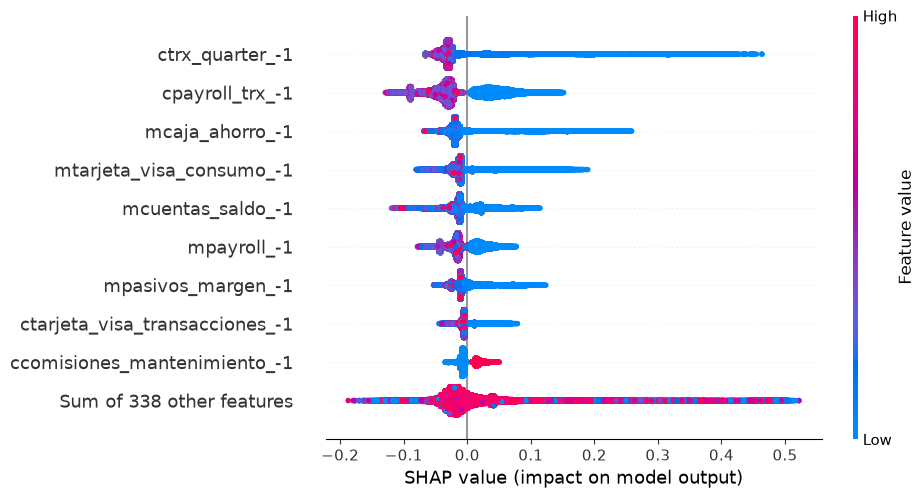

In [33]:
shap.plots.beeswarm(shap_values)

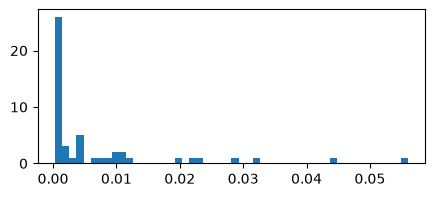

In [34]:
importancia_shap = np.abs(shap_values.values).mean(axis=0)
ranking_features = pd.Series(
    importancia_shap,
    index=campos_buenos,
    name="importancia_shap",
).sort_values(ascending=False)

plt.figure(figsize=(5, 2))
plt.hist(
    ranking_features.values[:50],
    bins=50,
)
plt.show()

# Clustering

## Subsampleamos, mantenemos los baja y sumamos una fraccion de continua

In [35]:
ternaria = df_clientes["grupo"]
mask_baja = ternaria.eq(1)
mask_continua = ternaria.eq(0)

df_bajas = df_clientes.loc[mask_baja]

df_continua = (
    df_clientes.loc[mask_continua]
    .sample(
        n=len(df_bajas) // 5,
        random_state=SEED,
    )
)

df_cluster = (
    pd.concat([df_bajas, df_continua])
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer(df_cluster[campos_buenos])

X_shap = shap_values.values.astype(np.float32, copy=False)
labels_reales = df_cluster["grupo"].to_numpy()


## Hierarchical sobre muestra subsampleada

In [36]:
ks = [3, 4, 5, 6]
linkages = ["ward", "complete", "average", "single"]
metrics = ["euclidean", "manhattan", "cosine"]

resultados_h = []

# X_shap mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = X_shap.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "X_shap y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for k in ks:

    for linkage in linkages:
        for metric in metrics:

            # Ward solamente admite distancia euclídea.
            if linkage == "ward" and metric != "euclidean":
                continue

            # Uso otro nombre para no sobrescribir el LightGBM.
            modelo_h = AgglomerativeClustering(
                n_clusters=k + 1,
                linkage=linkage,
                metric=metric,
            )

            labels = modelo_h.fit_predict(X_escalado)

            tamanios_clusters = (
                pd.Series(labels)
                .value_counts()
                .sort_index()
            )

            proporcion_cluster_mayor = (
                tamanios_clusters.max() / len(labels)
            )

            # Se descarta si algún cluster contiene
            # más del 50 % de las observaciones.
            if proporcion_cluster_mayor > 0.50:
                continue

            column_name = (
                f"agg-{k}-{linkage}-{metric}"
            )

            df_cluster[column_name] = labels

            # Distribución de BAJA/CONTINUA en cada cluster.
            composicion_grupos = (
                pd.crosstab(
                    pd.Series(labels, name="cluster"),
                    pd.Series(
                        labels_reales,
                        name="grupo",
                    ),
                )
                .to_dict()
            )

            resultados_h.append({
                "column_name": column_name,
                "k_baja": k,
                "clusters_totales": k + 1,
                "linkage": linkage,
                "metric": metric,
                "columnas_usadas": X.shape[1],
                "silhouette": silhouette_score(
                    X_escalado,
                    labels,
                ),
                "davies_bouldin": davies_bouldin_score(
                    X_escalado,
                    labels,
                ),
                "calinski_harabasz": calinski_harabasz_score(
                    X_escalado,
                    labels,
                ),
                "tamanios_clusters": (
                    pd.Series(labels)
                    .value_counts()
                    .sort_index()
                    .to_dict()
                ),
                "composicion_grupos": composicion_grupos,
            })

tabla_resultados_h = pd.DataFrame(
    resultados_h
)

/tmp/ipykernel_374642/975268770.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/975268770.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/975268770.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram

In [37]:
tabla_resultados_h.sort_values(by='silhouette', ascending=False)

,column_name,k_baja,clusters_totales,linkage,metric,columnas_usadas,silhouette,davies_bouldin,calinski_harabasz,tamanios_clusters,composicion_grupos
7,agg-5-complete-cosine,5,6,complete,cosine,347,0.032349,6.345040,106.208223,"{0: 1187, 1: 2104, 2: 1144, 3: 337, 4: 519, 5:...","{0: {0: 106, 1: 349, 2: 183, 3: 119, 4: 118, 5..."
1,agg-3-complete-cosine,3,4,complete,cosine,347,0.032161,5.978285,150.298519,"{0: 1706, 1: 2104, 2: 1949, 3: 337}","{0: {0: 224, 1: 349, 2: 324, 3: 119}, 1: {0: 1..."
4,agg-4-complete-cosine,4,5,complete,cosine,347,0.029418,5.572531,125.582018,"{0: 1949, 1: 2104, 2: 1187, 3: 337, 4: 519}","{0: {0: 324, 1: 349, 2: 106, 3: 119, 4: 118}, ..."
6,agg-5-ward-euclidean,5,6,ward,euclidean,347,0.027275,4.289489,178.786103,"{0: 1383, 1: 445, 2: 1236, 3: 1545, 4: 792, 5:...","{0: {0: 335, 1: 231, 2: 51, 3: 85, 4: 100, 5: ..."
3,agg-4-ward-euclidean,4,5,ward,euclidean,347,0.022169,3.942194,199.592950,"{0: 2240, 1: 1383, 2: 1236, 3: 445, 4: 792}","{0: {0: 299, 1: 335, 2: 51, 3: 231, 4: 100}, 1..."
0,agg-3-ward-euclidean,3,4,ward,euclidean,347,0.010145,4.006612,224.627812,"{0: 2175, 1: 2240, 2: 1236, 3: 445}","{0: {0: 435, 1: 299, 2: 51, 3: 231}, 1: {0: 17..."
10,agg-6-complete-cosine,6,7,complete,cosine,347,-0.005123,6.513523,100.307611,"{0: 2104, 1: 519, 2: 1144, 3: 337, 4: 760, 5: ...","{0: {0: 349, 1: 118, 2: 183, 3: 119, 4: 34, 5:..."
9,agg-6-ward-euclidean,6,7,ward,euclidean,347,-0.007362,4.086541,164.369597,"{0: 1236, 1: 445, 2: 676, 3: 1545, 4: 792, 5: ...","{0: {0: 51, 1: 231, 2: 314, 3: 85, 4: 100, 5: ..."
11,agg-6-average-cosine,6,7,average,cosine,347,-0.014447,4.009015,126.416719,"{0: 1199, 1: 239, 2: 1134, 3: 2153, 4: 76, 5: ...","{0: {0: 362, 1: 145, 2: 14, 3: 426, 4: 13, 5: ..."
8,agg-5-average-cosine,5,6,average,cosine,347,-0.014603,4.272401,150.176729,"{0: 1205, 1: 239, 2: 1134, 3: 2153, 4: 76, 5: ...","{0: {0: 363, 1: 145, 2: 14, 3: 426, 4: 13, 5: ..."


## k-means sobre muestra subsampleada

In [38]:
ks = [3, 4, 5, 6]
resultados = []

# X_shap mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = X_shap.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "X_shap y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for k in ks:

    kmeans = KMeans(
        n_clusters=k + 1,
        n_init=20,
        random_state=SEED,
    )

    column_name = f"k-means-{k}"

    labels = kmeans.fit_predict(X_escalado)

    df_cluster[column_name] = labels

    # Distribución de BAJA/CONTINUA en cada cluster.
    composicion_grupos = (
        pd.crosstab(
            pd.Series(labels, name="cluster"),
            pd.Series(
                labels_reales,
                name="grupo",
            ),
        )
        .to_dict()
    )

    resultados.append({
        "column_name": column_name,
        "k_baja": k,
        "clusters_totales": k + 1,
        "tamanios_clusters": (
            pd.Series(labels)
            .value_counts()
            .sort_index()
            .to_dict()
        ),
        "ncolumnas_usadas": X.shape[1],
        "inercia": kmeans.inertia_,
        "iteraciones": kmeans.n_iter_,
        "silhouette": silhouette_score(
            X_escalado,
            labels,
        ),
        "davies_bouldin": davies_bouldin_score(
            X_escalado,
            labels,
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_escalado,
            labels,
        ),
        "composicion_grupos": composicion_grupos,
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(
    "silhouette",
    ascending=False,
)

/tmp/ipykernel_374642/295410976.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/295410976.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/295410976.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram

,column_name,k_baja,clusters_totales,tamanios_clusters,ncolumnas_usadas,inercia,iteraciones,silhouette,davies_bouldin,calinski_harabasz,composicion_grupos
2,k-means-5,5,6,"{0: 1627, 1: 836, 2: 458, 3: 959, 4: 928, 5: 1...",347,1388554.250,50,0.007043,3.992479,199.017409,"{0: {0: 102, 1: 243, 2: 227, 3: 5, 4: 200, 5: ..."
1,k-means-4,4,5,"{0: 1025, 1: 607, 2: 1086, 3: 2093, 4: 1285}",347,1411182.625,56,0.004333,3.765933,220.405957,"{0: {0: 8, 1: 270, 2: 321, 3: 179, 4: 238}, 1:..."
3,k-means-6,6,7,"{0: 485, 1: 907, 2: 818, 3: 966, 4: 1704, 5: 7...",347,1372617.250,51,-0.001743,3.710629,179.528717,"{0: {0: 183, 1: 194, 2: 56, 3: 5, 4: 100, 5: 2..."
0,k-means-3,3,4,"{0: 2266, 1: 624, 2: 2190, 3: 1016}",347,1440749.750,29,-0.018504,3.710259,246.217208,"{0: {0: 239, 1: 274, 2: 498, 3: 5}, 1: {0: 202..."


## DBSCAN sobre muestra subsampleada

In [39]:
from sklearn.cluster import DBSCAN
eps_values = [0.001, 0.055, 0.06,0.065, 0.07,0.075,0.08, 0.085,0.09]
min_samples_values = [2, 3, 5,10,20,30,50]
resultados_dbscan = []

# umap_nd mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = X_shap.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "X_shap y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for eps in eps_values:
    for min_samples in min_samples_values:

        modelo_dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            n_jobs=-1,
        )

        labels = modelo_dbscan.fit_predict(
            X_escalado
        )

        # DBSCAN identifica el ruido con la etiqueta -1.
        mask_sin_ruido = labels != -1

        labels_sin_ruido = labels[
            mask_sin_ruido
        ]

        clusters = np.unique(
            labels_sin_ruido
        )

        cantidad_clusters = len(clusters)

        # Se necesitan al menos dos clusters para
        # calcular las métricas.
        if cantidad_clusters < 2:
            continue

        tamanios_clusters = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        # Para este filtro, el ruido (-1) se considera
        # un cluster más.
        proporcion_cluster_mayor = (
            tamanios_clusters.max()
            / len(labels)
        )

        # Se descarta si cualquier grupo, incluido el ruido,
        # contiene más del 50 % de los puntos.
        if proporcion_cluster_mayor > 0.50:
            continue

        cantidad_ruido = int(
            np.sum(~mask_sin_ruido)
        )

        proporcion_ruido = (
            cantidad_ruido / len(labels)
        )

        eps_texto = str(eps).replace(".", "p")

        column_name = (
            f"dbscan-eps{eps_texto}"
            f"-min{min_samples}"
        )

        df_cluster[column_name] = labels

        # Las métricas se calculan sin los puntos
        # identificados como ruido.
        X_sin_ruido = X_escalado[
            mask_sin_ruido
        ]

        composicion_grupos = (
            pd.crosstab(
                pd.Series(
                    labels,
                    name="cluster",
                ),
                pd.Series(
                    labels_reales,
                    name="grupo",
                ),
            )
            .to_dict()
        )

        resultados_dbscan.append({
            "column_name": column_name,
            "eps": eps,
            "min_samples": min_samples,
            # "clusters_totales": cantidad_clusters,
            "clusters_totales": len(tamanios_clusters),
            "cantidad_ruido": cantidad_ruido,
            "proporcion_ruido": proporcion_ruido,
            "proporcion_cluster_mayor": (
                proporcion_cluster_mayor
            ),
            "columnas_usadas": X.shape[1],
            "silhouette": silhouette_score(
                X_sin_ruido,
                labels_sin_ruido,
            ),
            "davies_bouldin": (
                davies_bouldin_score(
                    X_sin_ruido,
                    labels_sin_ruido,
                )
            ),
            "calinski_harabasz": (
                calinski_harabasz_score(
                    X_sin_ruido,
                    labels_sin_ruido,
                )
            ),
            "tamanios_clusters": (
                tamanios_clusters.to_dict()
            ),
            "composicion_grupos": (
                composicion_grupos
            ),
        })

tabla_resultados_dbscan = pd.DataFrame(
    resultados_dbscan
)

In [40]:
tabla_resultados_dbscan

""


## Reducimos dimensionalidad con UMAP

In [41]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"build_algo='nn_descent' is not deterministic.*",
    category=UserWarning,
)

resultados_umap = evaluar_umap_kmeans(
    X_shap=X_shap,
    N_COMPONENTS=[2, 3, 5, 7, 10],
    N_NEIGHBORS=[ 20, 30, 40, 50],
    MIN_DIST=[0.001, 0.1, 0.01],
    METRICS=["euclidean", "cosine"],
    N_CLUSTERS=[3, 4, 5, 6],
    N_SEEDS=3,
    SAMPLE_FRAC=1,
    SEED=SEED,
)

KeyboardInterrupt: 

In [44]:
filename = 'umap_shap_ouput_dim_red_cons.csv'
output_file = os.path.join( os.getcwd(),  filename)
# resultados_umap.to_csv(filename)
resultados_umap = pd.read_csv(filename, index_col=0)

In [46]:
resultados_umap.sort_values(by='sil', ascending=False).head(20)

,n_clusters,n_components,n_neighbors,min_dist,metric,sil,db,ch,ari_estabilidad,nmi_estabilidad,vdn_estabilidad,s_sil,s_db,s_ch,s_ari,s_nmi,s_vdn
283,6,5,50,0.010,euclidean,0.592364,0.628381,7720.773531,0.962421,0.960393,0.033719,0.005138,0.127563,185.194879,0.010843,0.008728,0.008611
79,6,2,50,0.001,cosine,0.579870,0.573566,12027.920588,0.852311,0.886038,0.090012,0.010980,0.016580,70.274279,0.043203,0.023916,0.025984
163,6,3,40,0.010,euclidean,0.577991,0.629249,9694.590715,0.925125,0.945642,0.038736,0.001921,0.017608,123.419530,0.020870,0.012130,0.010907
247,6,5,40,0.001,cosine,0.577501,0.770501,5792.000549,0.819839,0.900917,0.122608,0.033891,0.155113,386.925574,0.072786,0.034065,0.046080
243,6,5,40,0.001,euclidean,0.576401,0.570369,6846.291800,0.999703,0.999445,0.000169,0.001642,0.001048,63.692351,0.000210,0.000392,0.000120
363,6,7,50,0.001,euclidean,0.576152,0.778012,6598.209770,0.844356,0.908718,0.095844,0.014820,0.149543,264.063814,0.109764,0.064017,0.067616
282,5,5,50,0.010,euclidean,0.576105,0.624207,7635.000693,0.998394,0.997429,0.000844,0.003852,0.005382,63.397132,0.000847,0.001253,0.000430
270,5,5,50,0.001,cosine,0.575457,0.613282,5968.690775,0.842223,0.898819,0.090952,0.004787,0.029196,94.457679,0.092031,0.051071,0.050891
267,6,5,50,0.001,euclidean,0.575256,0.759322,8051.911241,0.849408,0.911622,0.110342,0.012812,0.037194,191.565380,0.105990,0.061462,0.077713
286,5,5,50,0.010,cosine,0.574927,0.609368,5975.942840,0.861702,0.919453,0.077713,0.004870,0.026795,42.580470,0.097791,0.056955,0.054952


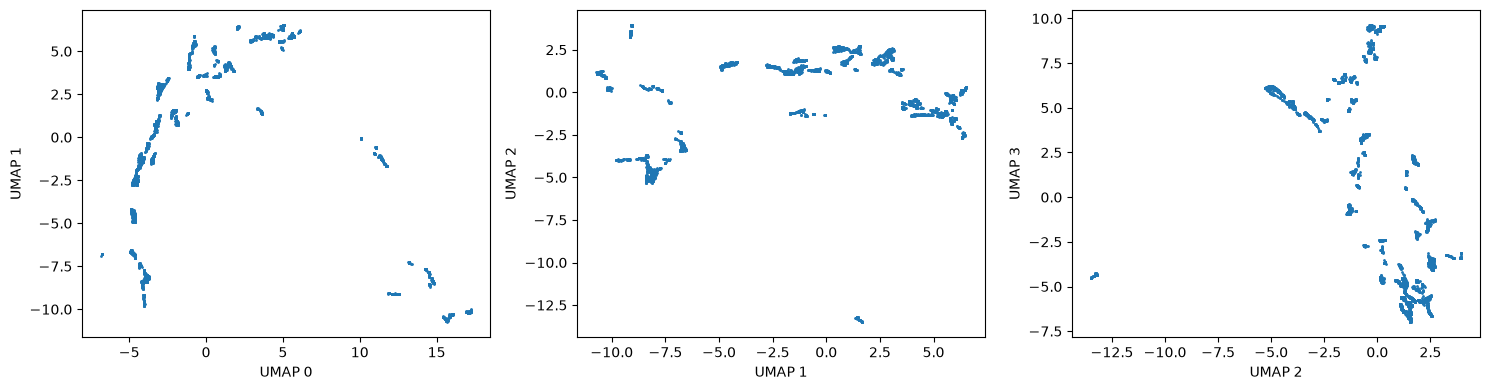

In [47]:
umap_nd = UMAP(
    n_components=5,
    n_neighbors=40,
    min_dist=0.001,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
# for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_nd[:, x], umap_nd[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

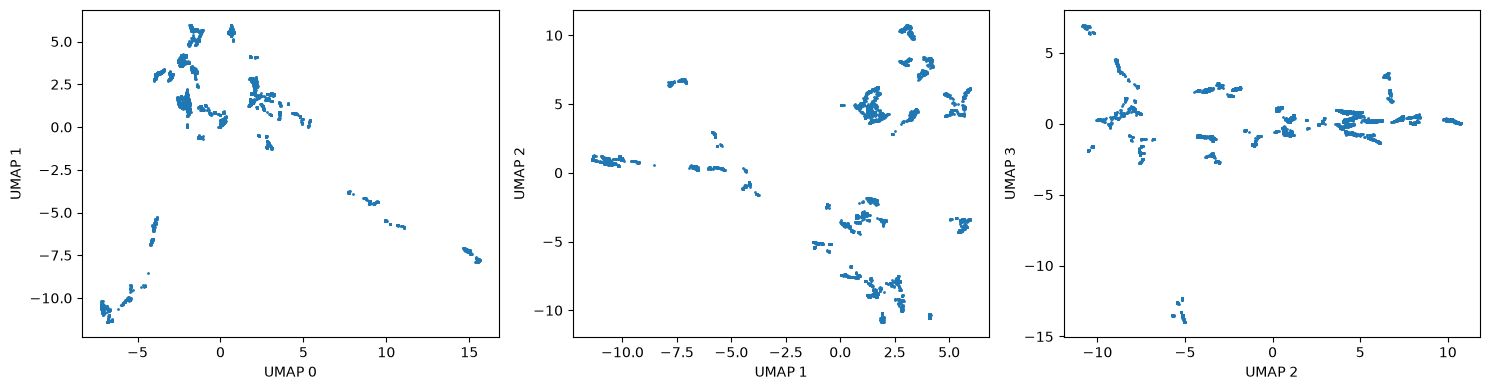

In [48]:
umap_nd = UMAP(
    n_components=5,
    n_neighbors=40,
    min_dist=0.001,
    metric='cosine',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
# for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_nd[:, x], umap_nd[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

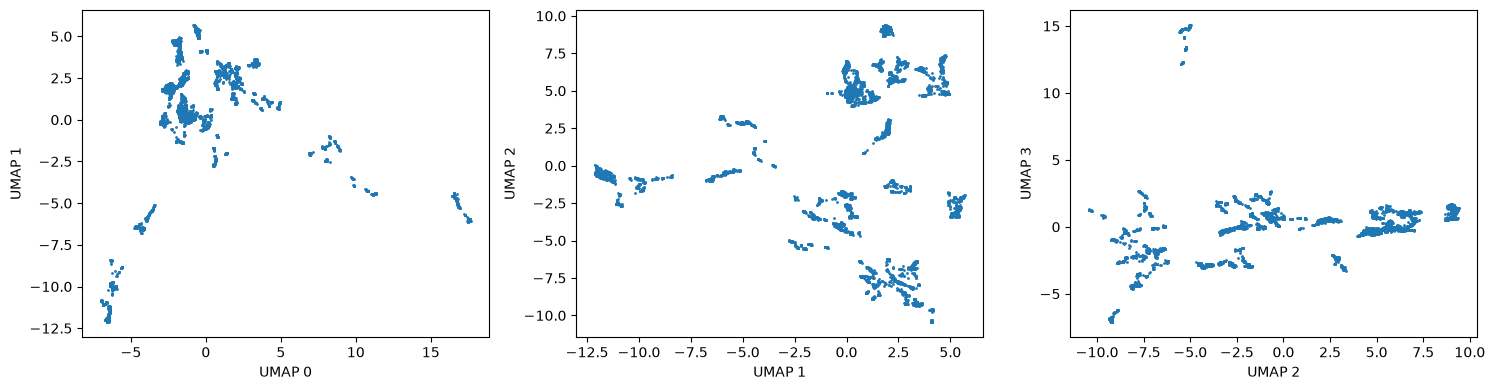

In [49]:
umap_nd = UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
# for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_nd[:, x], umap_nd[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

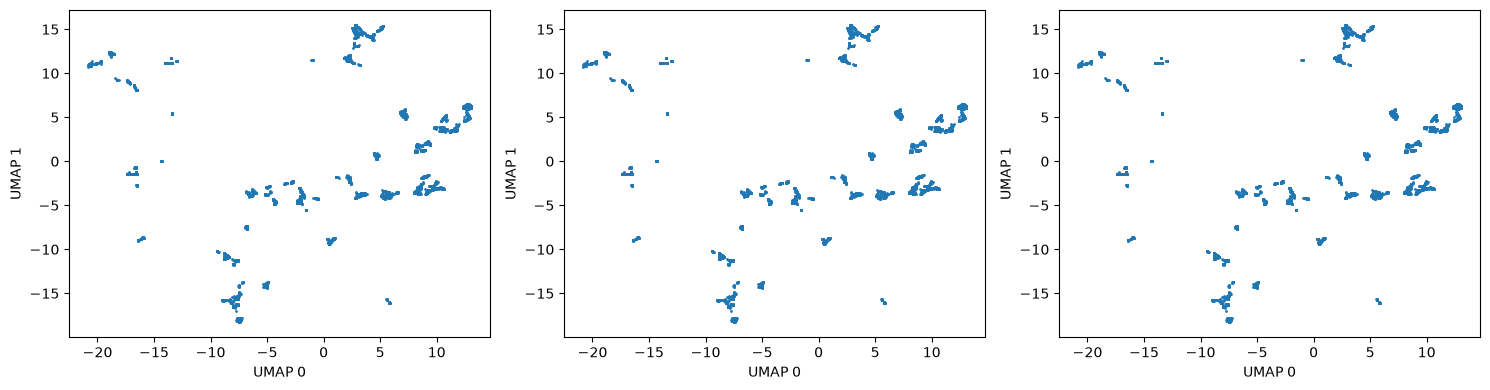

In [50]:
umap_nd = UMAP(
    n_components=2,
    n_neighbors=40,
    min_dist=0.001,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_nd[:, x], umap_nd[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

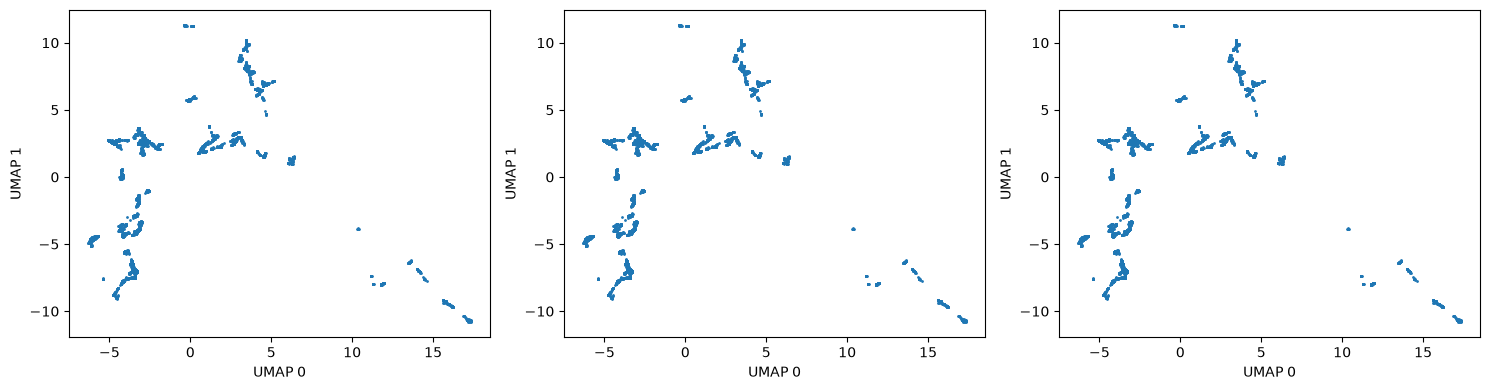

In [51]:
umap_nd = UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.001,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_nd[:, x], umap_nd[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

## K-means sobre UMAP

In [52]:
umap_nd = UMAP(
    n_components=5,
    n_neighbors=40,
    min_dist=0.001,
    metric='cosine',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)


In [53]:
umap_nd.shape, X_shap.shape, labels_reales.shape

((6096, 5), (6096, 347), (6096,))

In [54]:
ks = [3, 4, 5, 6]
resultados = []

# X_shap mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = umap_nd.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "X_shap y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for k in ks:

    kmeans = KMeans(
        n_clusters=k + 1,
        n_init=20,
        random_state=SEED,
    )

    column_name = f"k-means-{k}"

    labels = kmeans.fit_predict(X_escalado)

    df_cluster[column_name] = labels

    # Distribución de BAJA/CONTINUA en cada cluster.
    composicion_grupos = (
        pd.crosstab(
            pd.Series(labels, name="cluster"),
            pd.Series(
                labels_reales,
                name="grupo",
            ),
        )
        .to_dict()
    )

    resultados.append({
        "column_name": column_name,
        "k_baja": k,
        "clusters_totales": k + 1,
        "tamanios_clusters": (
            pd.Series(labels)
            .value_counts()
            .sort_index()
            .to_dict()
        ),
        "ncolumnas_usadas": X.shape[1],
        "inercia": kmeans.inertia_,
        "iteraciones": kmeans.n_iter_,
        "silhouette": silhouette_score(
            X_escalado,
            labels,
        ),
        "davies_bouldin": davies_bouldin_score(
            X_escalado,
            labels,
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_escalado,
            labels,
        ),
        "composicion_grupos": composicion_grupos,
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(
    "silhouette",
    ascending=False,
)

,column_name,k_baja,clusters_totales,tamanios_clusters,ncolumnas_usadas,inercia,iteraciones,silhouette,davies_bouldin,calinski_harabasz,composicion_grupos
2,k-means-5,5,6,"{0: 1009, 1: 1732, 2: 1982, 3: 182, 4: 455, 5:...",5,5051.067871,3,0.611945,0.546411,6131.860866,"{0: {0: 280, 1: 131, 2: 55, 3: 0, 4: 1, 5: 549..."
3,k-means-6,6,7,"{0: 1009, 1: 1008, 2: 736, 3: 1732, 4: 974, 5:...",5,3804.685791,7,0.591546,0.594366,7115.173680,"{0: {0: 280, 1: 36, 2: 549, 3: 131, 4: 19, 5: ..."
1,k-means-4,4,5,"{0: 455, 1: 1982, 2: 1732, 3: 1191, 4: 736}",5,8499.919922,2,0.567350,0.731954,3937.703525,"{0: {0: 1, 1: 55, 2: 131, 3: 280, 4: 549}, 1: ..."
0,k-means-3,3,4,"{0: 1732, 1: 918, 2: 2991, 3: 455}",5,13648.857422,2,0.426917,1.012613,2504.125425,"{0: {0: 131, 1: 549, 2: 335, 3: 1}, 1: {0: 160..."


In [55]:
pd.set_option('display.max_colwidth', 100)
tabla_resultados[['column_name','clusters_totales','tamanios_clusters']]

,column_name,clusters_totales,tamanios_clusters
0,k-means-3,4,"{0: 1732, 1: 918, 2: 2991, 3: 455}"
1,k-means-4,5,"{0: 455, 1: 1982, 2: 1732, 3: 1191, 4: 736}"
2,k-means-5,6,"{0: 1009, 1: 1732, 2: 1982, 3: 182, 4: 455, 5: 736}"
3,k-means-6,7,"{0: 1009, 1: 1008, 2: 736, 3: 1732, 4: 974, 5: 455, 6: 182}"


In [56]:
kmeans = KMeans(
    n_clusters=5,
    n_init=20,
    random_state=SEED,
)
umap_nd_escalado = StandardScaler().fit_transform(X)
labels = kmeans.fit_predict(umap_nd_escalado)
composicion_grupos = (
    pd.crosstab(
        pd.Series(labels, name="cluster"),
        pd.Series(
            labels_reales,
            name="grupo",
        ),
    )
    .to_dict()
)
composicion_grupos

{0: {0: 1, 1: 55, 2: 131, 3: 280, 4: 549},
 1: {0: 454, 1: 1927, 2: 1601, 3: 911, 4: 187}}

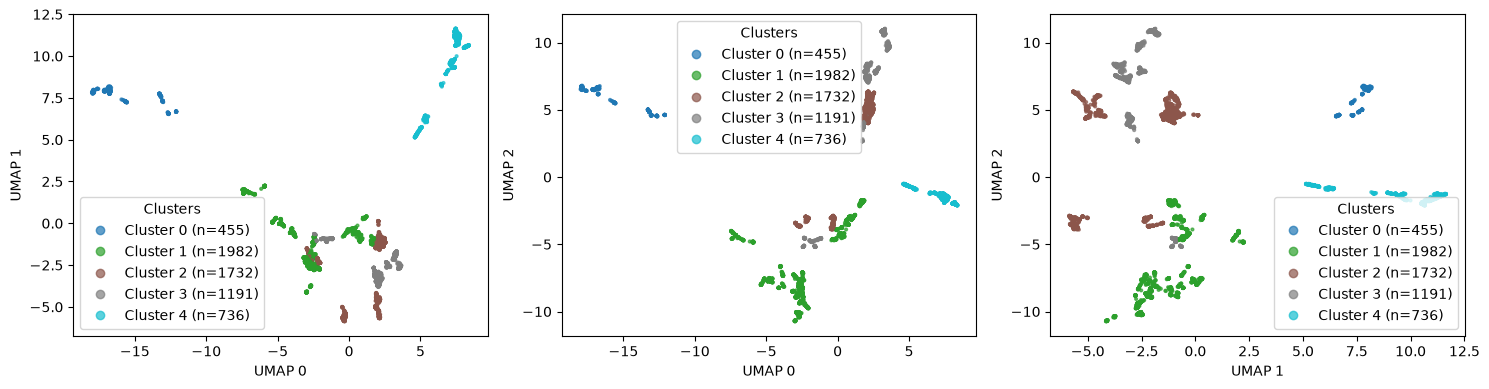

In [57]:
clusters, cantidades = np.unique(
    labels,
    return_counts=True,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

for ax, (x, y) in zip(
    axes,
    [(0, 1), (0, 2), (1, 2)],
):
    scatter = ax.scatter(
        umap_nd[:, x],
        umap_nd[:, y],
        c=labels,
        cmap="tab10",
        s=4,
        alpha=0.7,
    )

    ax.set(
        xlabel=f"UMAP {x}",
        ylabel=f"UMAP {y}",
    )

    handles, _ = scatter.legend_elements()

    etiquetas = [
        f"Cluster {cluster} (n={cantidad})"
        for cluster, cantidad
        in zip(clusters, cantidades)
    ]

    ax.legend(
        handles,
        etiquetas,
        title="Clusters",
    )

plt.tight_layout()
plt.show()

## Hierarchical sobre umap

In [58]:
ks = [3, 4, 5, 6]
linkages = ["ward", "complete", "average", "single"]
metrics = ["euclidean", "manhattan", "cosine"]

resultados_h = []

# X_shap mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = umap_nd.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "X_shap y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for k in ks:

    for linkage in linkages:
        for metric in metrics:

            # Ward solamente admite distancia euclídea.
            if linkage == "ward" and metric != "euclidean":
                continue

            # Uso otro nombre para no sobrescribir el LightGBM.
            modelo_h = AgglomerativeClustering(
                n_clusters=k + 1,
                linkage=linkage,
                metric=metric,
            )

            labels = modelo_h.fit_predict(X_escalado)

            tamanios_clusters = (
                pd.Series(labels)
                .value_counts()
                .sort_index()
            )

            proporcion_cluster_mayor = (
                tamanios_clusters.max() / len(labels)
            )

            # Se descarta si algún cluster contiene
            # más del 50 % de las observaciones.
            if proporcion_cluster_mayor > 0.50:
                continue

            column_name = (
                f"agg-{k}-{linkage}-{metric}"
            )

            df_cluster[column_name] = labels

            # Distribución de BAJA/CONTINUA en cada cluster.
            composicion_grupos = (
                pd.crosstab(
                    pd.Series(labels, name="cluster"),
                    pd.Series(
                        labels_reales,
                        name="grupo",
                    ),
                )
                .to_dict()
            )

            resultados_h.append({
                "column_name": column_name,
                "k_baja": k,
                "clusters_totales": k + 1,
                "linkage": linkage,
                "metric": metric,
                "columnas_usadas": X.shape[1],
                "silhouette": silhouette_score(
                    X_escalado,
                    labels,
                ),
                "davies_bouldin": davies_bouldin_score(
                    X_escalado,
                    labels,
                ),
                "calinski_harabasz": calinski_harabasz_score(
                    X_escalado,
                    labels,
                ),
                "tamanios_clusters": (
                    pd.Series(labels)
                    .value_counts()
                    .sort_index()
                    .to_dict()
                ),
                "composicion_grupos": composicion_grupos,
            })

tabla_resultados_h = pd.DataFrame(
    resultados_h
)

/tmp/ipykernel_374642/305982647.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/305982647.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/305982647.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram

In [59]:
tabla_resultados_h.sort_values(by='silhouette', ascending=False).head()

,column_name,k_baja,clusters_totales,linkage,metric,columnas_usadas,silhouette,davies_bouldin,calinski_harabasz,tamanios_clusters,composicion_grupos
25,agg-6-average-euclidean,6,7,average,euclidean,5,0.617110,0.504630,6718.811681,"{0: 1732, 1: 736, 2: 1789, 3: 182, 4: 1009, 5: 455, 6: 193}","{0: {0: 131, 1: 549, 2: 53, 3: 0, 4: 280, 5: 1, 6: 2}, 1: {0: 1601, 1: 187, 2: 1736, 3: 182, 4: ..."
22,agg-6-complete-euclidean,6,7,complete,euclidean,5,0.617110,0.504630,6718.811681,"{0: 1732, 1: 1789, 2: 736, 3: 182, 4: 455, 5: 1009, 6: 193}","{0: {0: 131, 1: 53, 2: 549, 3: 0, 4: 1, 5: 280, 6: 2}, 1: {0: 1601, 1: 1736, 2: 187, 3: 182, 4: ..."
21,agg-6-ward-euclidean,6,7,ward,euclidean,5,0.617110,0.504630,6718.811681,"{0: 1732, 1: 1009, 2: 1789, 3: 455, 4: 736, 5: 182, 6: 193}","{0: {0: 131, 1: 280, 2: 53, 3: 1, 4: 549, 5: 0, 6: 2}, 1: {0: 1601, 1: 729, 2: 1736, 3: 454, 4: ..."
26,agg-6-average-manhattan,6,7,average,manhattan,5,0.617110,0.504630,6718.811681,"{0: 1732, 1: 1789, 2: 455, 3: 182, 4: 736, 5: 1009, 6: 193}","{0: {0: 131, 1: 53, 2: 1, 3: 0, 4: 549, 5: 280, 6: 2}, 1: {0: 1601, 1: 1736, 2: 454, 3: 182, 4: ..."
12,agg-5-complete-euclidean,5,6,complete,euclidean,5,0.611945,0.546411,6131.860866,"{0: 1982, 1: 1732, 2: 736, 3: 182, 4: 455, 5: 1009}","{0: {0: 55, 1: 131, 2: 549, 3: 0, 4: 1, 5: 280}, 1: {0: 1927, 1: 1601, 2: 187, 3: 182, 4: 454, 5..."


In [60]:
modelo_h = AgglomerativeClustering(
    n_clusters=6,
    linkage='complete',
    metric='euclidean',
)
umap_nd_escalado = StandardScaler().fit_transform(X)
labels = modelo_h.fit_predict(umap_nd_escalado)

In [61]:
composicion_grupos = (
    pd.crosstab(
        pd.Series(labels, name="cluster"),
        pd.Series(
            labels_reales,
            name="grupo",
        ),
    )
    .to_dict()
)
composicion_grupos

{0: {0: 55, 1: 131, 2: 549, 3: 0, 4: 1, 5: 280},
 1: {0: 1927, 1: 1601, 2: 187, 3: 182, 4: 454, 5: 729}}

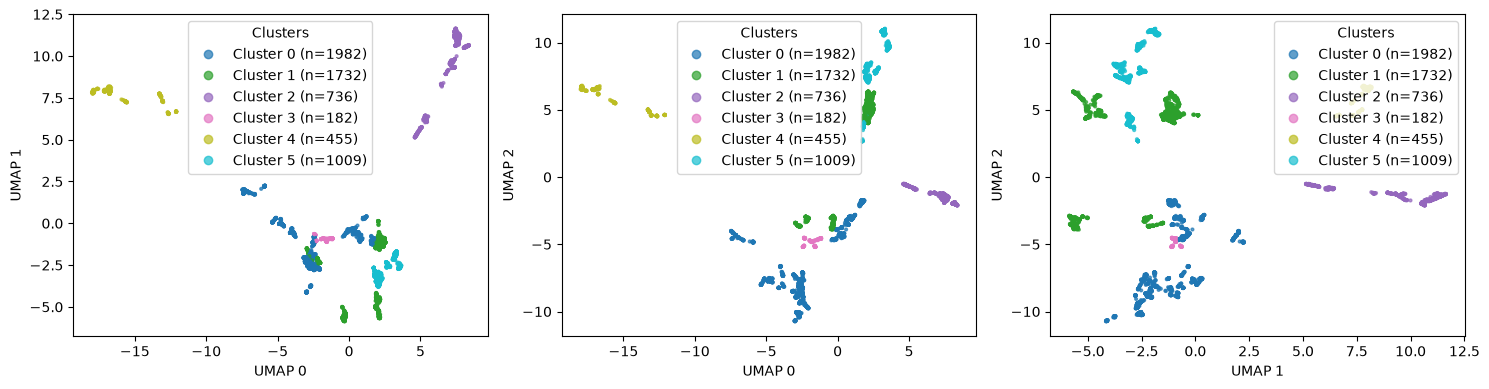

In [62]:
clusters, cantidades = np.unique(
    labels,
    return_counts=True,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

for ax, (x, y) in zip(
    axes,
    [(0, 1), (0, 2), (1, 2)],
):
    scatter = ax.scatter(
        umap_nd[:, x],
        umap_nd[:, y],
        c=labels,
        cmap="tab10",
        s=4,
        alpha=0.7,
    )

    ax.set(
        xlabel=f"UMAP {x}",
        ylabel=f"UMAP {y}",
    )

    handles, _ = scatter.legend_elements()

    etiquetas = [
        f"Cluster {cluster} (n={cantidad})"
        for cluster, cantidad
        in zip(clusters, cantidades)
    ]

    ax.legend(
        handles,
        etiquetas,
        title="Clusters",
    )

plt.tight_layout()
plt.show()

## DBSCAN sobre UMAP

In [63]:
from sklearn.cluster import DBSCAN

eps_values = [    0.10,    0.25,    0.50,    0.75,    1.00,    1.50,    2.00,]

min_samples_values = [    5,    10,    20,    30,    50,]

resultados_dbscan = []

# umap_nd mantiene el mismo orden de filas que df_cluster.
labels_reales = df_cluster["grupo"].to_numpy()

X = umap_nd.astype(
    np.float32,
    copy=False,
)

if len(X) != len(labels_reales):
    raise ValueError(
        "umap_nd y df_cluster tienen distinta cantidad de filas"
    )

X_escalado = StandardScaler().fit_transform(X)

for eps in eps_values:
    for min_samples in min_samples_values:

        modelo_dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            n_jobs=-1,
        )

        labels = modelo_dbscan.fit_predict(
            X_escalado
        )

        # DBSCAN identifica el ruido con la etiqueta -1.
        mask_sin_ruido = labels != -1

        labels_sin_ruido = labels[
            mask_sin_ruido
        ]

        clusters = np.unique(
            labels_sin_ruido
        )

        cantidad_clusters = len(clusters)

        # Se necesitan al menos dos clusters para
        # calcular las métricas.
        if cantidad_clusters < 2:
            continue

        tamanios_clusters = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        # Para este filtro, el ruido (-1) se considera
        # un cluster más.
        proporcion_cluster_mayor = (
            tamanios_clusters.max()
            / len(labels)
        )

        # Se descarta si cualquier grupo, incluido el ruido,
        # contiene más del 50 % de los puntos.
        if proporcion_cluster_mayor > 0.50:
            continue
        
        cantidad_ruido = int(
            np.sum(~mask_sin_ruido)
        )

        proporcion_ruido = (
            cantidad_ruido / len(labels)
        )

        eps_texto = str(eps).replace(".", "p")

        column_name = (
            f"dbscan-eps{eps_texto}"
            f"-min{min_samples}"
        )

        df_cluster[column_name] = labels

        # Las métricas se calculan sin los puntos
        # identificados como ruido.
        X_sin_ruido = X_escalado[
            mask_sin_ruido
        ]

        composicion_grupos = (
            pd.crosstab(
                pd.Series(
                    labels,
                    name="cluster",
                ),
                pd.Series(
                    labels_reales,
                    name="grupo",
                ),
            )
            .to_dict()
        )

        resultados_dbscan.append({
            "column_name": column_name,
            "eps": eps,
            "min_samples": min_samples,
            "clusters_totales": cantidad_clusters,
            "cantidad_ruido": cantidad_ruido,
            "proporcion_ruido": proporcion_ruido,
            "proporcion_cluster_mayor": (
                proporcion_cluster_mayor
            ),
            "columnas_usadas": X.shape[1],
            "silhouette": silhouette_score(
                X_sin_ruido,
                labels_sin_ruido,
            ),
            "davies_bouldin": (
                davies_bouldin_score(
                    X_sin_ruido,
                    labels_sin_ruido,
                )
            ),
            "calinski_harabasz": (
                calinski_harabasz_score(
                    X_sin_ruido,
                    labels_sin_ruido,
                )
            ),
            "tamanios_clusters": (
                tamanios_clusters.to_dict()
            ),
            "composicion_grupos": (
                composicion_grupos
            ),
        })

tabla_resultados_dbscan = pd.DataFrame(
    resultados_dbscan
)

/tmp/ipykernel_374642/2972887453.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/2972887453.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster[column_name] = labels
/tmp/ipykernel_374642/2972887453.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf

In [64]:
tabla_resultados_dbscan

,column_name,eps,min_samples,clusters_totales,cantidad_ruido,proporcion_ruido,proporcion_cluster_mayor,columnas_usadas,silhouette,davies_bouldin,calinski_harabasz,tamanios_clusters,composicion_grupos
0,dbscan-eps0p1-min5,0.10,5,45,0,0.000000,0.083661,5,0.704126,0.367651,49922.847377,"{0: 328, 1: 442, 2: 308, 3: 178, 4: 98, 5: 27, 6: 194, 7: 308, 8: 193, 9: 130, 10: 29, 11: 122, ...","{0: {0: 39, 1: 41, 2: 11, 3: 3, 4: 7, 5: 0, 6: 1, 7: 63, 8: 2, 9: 51, 10: 29, 11: 1, 12: 38, 13:..."
1,dbscan-eps0p1-min10,0.10,10,45,4,0.000656,0.083661,5,0.704916,0.367212,50210.785448,"{-1: 4, 0: 328, 1: 442, 2: 304, 3: 178, 4: 98, 5: 27, 6: 194, 7: 308, 8: 193, 9: 130, 10: 29, 11...","{0: {-1: 0, 0: 39, 1: 41, 2: 11, 3: 3, 4: 7, 5: 0, 6: 1, 7: 63, 8: 2, 9: 51, 10: 29, 11: 1, 12: ..."
2,dbscan-eps0p1-min20,0.10,20,44,49,0.008038,0.083661,5,0.742368,0.355541,53296.262965,"{-1: 49, 0: 328, 1: 442, 2: 303, 3: 146, 4: 98, 5: 27, 6: 183, 7: 308, 8: 193, 9: 130, 10: 29, 1...","{0: {-1: 0, 0: 39, 1: 41, 2: 11, 3: 2, 4: 7, 5: 0, 6: 1, 7: 63, 8: 2, 9: 51, 10: 29, 11: 1, 12: ..."
3,dbscan-eps0p1-min30,0.10,30,41,195,0.031988,0.083661,5,0.722970,0.370511,64350.939281,"{-1: 195, 0: 328, 1: 383, 2: 174, 3: 146, 4: 98, 5: 180, 6: 308, 7: 193, 8: 130, 9: 128, 10: 122...","{0: {-1: 48, 0: 39, 1: 31, 2: 4, 3: 2, 4: 7, 5: 1, 6: 63, 7: 2, 8: 51, 9: 6, 10: 1, 11: 38, 12: ..."
4,dbscan-eps0p1-min50,0.10,50,36,674,0.110564,0.110564,5,0.713072,0.384107,79729.129139,"{-1: 674, 0: 328, 1: 152, 2: 146, 3: 98, 4: 140, 5: 308, 6: 180, 7: 130, 8: 128, 9: 121, 10: 215...","{0: {-1: 55, 0: 39, 1: 2, 2: 2, 3: 7, 4: 1, 5: 63, 6: 2, 7: 51, 8: 6, 9: 1, 10: 38, 11: 31, 12: ..."
5,dbscan-eps0p25-min5,0.25,5,21,0,0.000000,0.090715,5,0.723939,0.415129,32846.657066,"{0: 328, 1: 442, 2: 511, 3: 182, 4: 257, 5: 237, 6: 439, 7: 193, 8: 330, 9: 264, 10: 339, 11: 24...","{0: {0: 39, 1: 41, 2: 14, 3: 7, 4: 3, 5: 2, 6: 94, 7: 2, 8: 130, 9: 221, 10: 1, 11: 56, 12: 34, ..."
6,dbscan-eps0p25-min10,0.25,10,21,0,0.000000,0.090715,5,0.723939,0.415129,32846.657066,"{0: 328, 1: 442, 2: 511, 3: 182, 4: 257, 5: 237, 6: 439, 7: 193, 8: 330, 9: 264, 10: 339, 11: 24...","{0: {0: 39, 1: 41, 2: 14, 3: 7, 4: 3, 5: 2, 6: 94, 7: 2, 8: 130, 9: 221, 10: 1, 11: 56, 12: 34, ..."
7,dbscan-eps0p25-min20,0.25,20,21,0,0.000000,0.090715,5,0.723939,0.415129,32846.657066,"{0: 328, 1: 442, 2: 511, 3: 182, 4: 257, 5: 237, 6: 439, 7: 193, 8: 330, 9: 264, 10: 339, 11: 24...","{0: {0: 39, 1: 41, 2: 14, 3: 7, 4: 3, 5: 2, 6: 94, 7: 2, 8: 130, 9: 221, 10: 1, 11: 56, 12: 34, ..."
8,dbscan-eps0p25-min30,0.25,30,21,0,0.000000,0.090715,5,0.723939,0.415129,32846.657066,"{0: 328, 1: 442, 2: 511, 3: 182, 4: 257, 5: 237, 6: 439, 7: 193, 8: 330, 9: 339, 10: 240, 11: 52...","{0: {0: 39, 1: 41, 2: 14, 3: 7, 4: 3, 5: 2, 6: 94, 7: 2, 8: 130, 9: 1, 10: 56, 11: 34, 12: 10, 1..."
9,dbscan-eps0p25-min50,0.25,50,21,27,0.004429,0.090715,5,0.725099,0.413959,32772.461328,"{-1: 27, 0: 328, 1: 442, 2: 511, 3: 182, 4: 257, 5: 237, 6: 439, 7: 193, 8: 330, 9: 312, 10: 240...","{0: {-1: 0, 0: 39, 1: 41, 2: 14, 3: 7, 4: 3, 5: 2, 6: 94, 7: 2, 8: 130, 9: 1, 10: 56, 11: 34, 12..."


In [65]:
modelo_dbscan = DBSCAN(
    eps=1,
    min_samples=50,
    metric="euclidean",
    n_jobs=-1,
)

labels = modelo_dbscan.fit_predict(
    X_escalado
)
composicion_grupos = (
    pd.crosstab(
        pd.Series(
            labels,
            name="cluster",
        ),
        pd.Series(
            labels_reales,
            name="grupo",
        ),
    )
    .to_dict()
)
composicion_grupos

{0: {0: 114, 1: 53, 2: 17, 3: 280, 4: 2, 5: 549, 6: 1, 7: 0},
 1: {0: 1184, 1: 1736, 2: 417, 3: 729, 4: 191, 5: 187, 6: 454, 7: 182}}

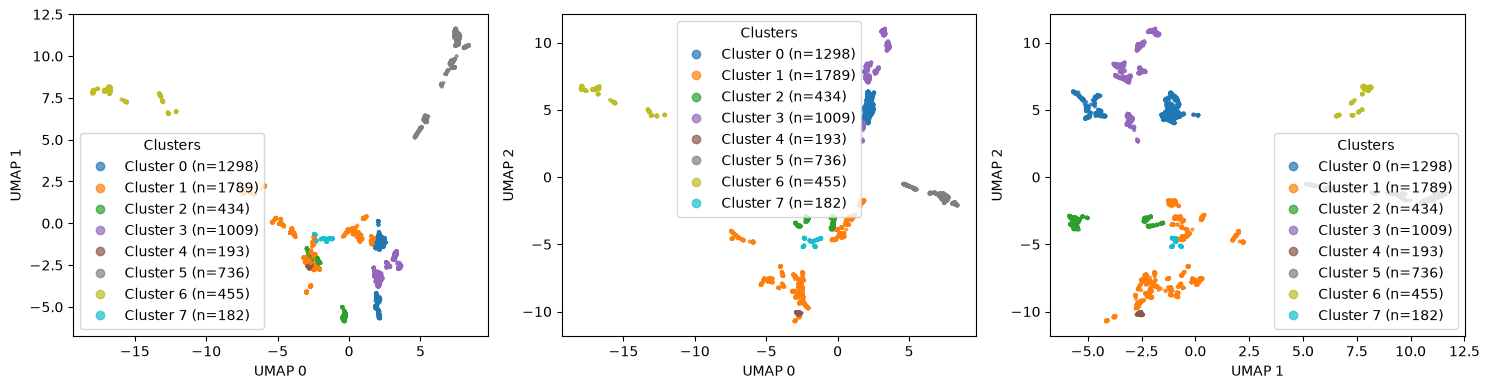

In [66]:
clusters, cantidades = np.unique(
    labels,
    return_counts=True,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

for ax, (x, y) in zip(
    axes,
    [(0, 1), (0, 2), (1, 2)],
):
    scatter = ax.scatter(
        umap_nd[:, x],
        umap_nd[:, y],
        c=labels,
        cmap="tab10",
        s=4,
        alpha=0.7,
    )

    ax.set(
        xlabel=f"UMAP {x}",
        ylabel=f"UMAP {y}",
    )

    handles, _ = scatter.legend_elements()

    etiquetas = [
        f"Cluster {cluster} (n={cantidad})"
        for cluster, cantidad
        in zip(clusters, cantidades)
    ]

    ax.legend(
        handles,
        etiquetas,
        title="Clusters",
    )

plt.tight_layout()
plt.show()

In [69]:
labels.shape,labels_reales.shape, df_cluster.shape

((6096,), (6096,), (6096, 411))

In [70]:
df_cluster['dbscan_test']=labels
df_cluster.shape

/tmp/ipykernel_374642/530450512.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cluster['dbscan_test']=labels


(6096, 412)

In [76]:
clientes_clusters = df_cluster[['numero_de_cliente', 'dbscan_test']].copy()

In [78]:
df_clientes_2 = df_clientes.merge(df_cluster[['dbscan_test']], left_index=True, right_index=True, how='left')

In [82]:
df_clientes_2.shape, df_clientes.shape
df_clientes_2['dbscan_test'].value_counts(dropna=False)

dbscan_test
NaN    163631
1.0      1789
0.0      1298
3.0      1009
5.0       736
6.0       455
2.0       434
4.0       193
7.0       182
Name: count, dtype: int64

In [88]:
df_clientes_2

,numero_de_cliente,grupo,punto_0,ctrx_quarter_-1,ctrx_quarter_-2,ctrx_quarter_-3,ctrx_quarter_-4,mcaja_ahorro_-1,mcaja_ahorro_-2,mcaja_ahorro_-3,...,delta_mtransferencias_emitidas_-1_-2,delta_mtransferencias_emitidas_-2_-3,delta_mtransferencias_emitidas_-3_-4,delta_Visa_cconsumos_-1_-2,delta_Visa_cconsumos_-2_-3,delta_Visa_cconsumos_-3_-4,delta_Master_mlimitecompra_-1_-2,delta_Master_mlimitecompra_-2_-3,delta_Master_mlimitecompra_-3_-4,dbscan_test
0,12176834,1,202106,3.0,3.0,6.0,NaN,0.00,0.00,0.00,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,12188338,1,202105,33.0,80.0,NaN,NaN,0.00,0.00,NaN,...,0.0,NaN,NaN,-6.0,NaN,NaN,0.0,NaN,NaN,0.0
2,12198564,1,202106,55.0,55.0,43.0,NaN,25497.84,5698.55,571.46,...,-9149.4,3519.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,12200827,1,202105,25.0,23.0,NaN,NaN,975.60,1765.42,NaN,...,351.9,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,1.0
4,12218654,1,202104,5.0,NaN,NaN,NaN,910.90,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169722,78249586,0,202104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169723,78249850,0,202107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169724,78250419,0,202105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169725,78253625,0,202107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
df_clientes_2.loc[df_clientes_2['dbscan_test'].isna(),'dbscan_test' ] = 8
df_clientes_2['dbscan_test'].unique()

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [103]:
ranking_features[:10].index

Index(['ctrx_quarter_-1', 'cpayroll_trx_-1', 'mcaja_ahorro_-1',
       'mtarjeta_visa_consumo_-1', 'mcuentas_saldo_-1', 'mpayroll_-1',
       'mpasivos_margen_-1', 'ctarjeta_visa_transacciones_-1',
       'ccomisiones_mantenimiento_-1', 'mcuenta_corriente_-1'],
      dtype='str')

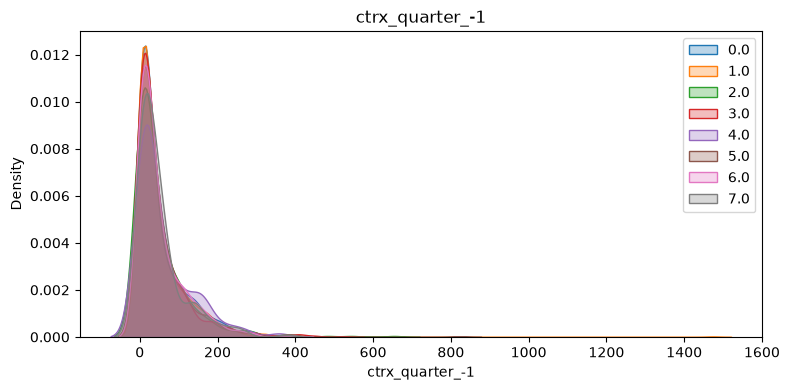

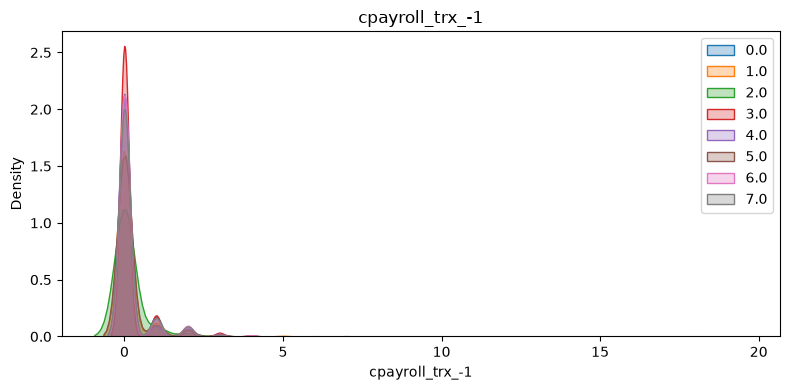

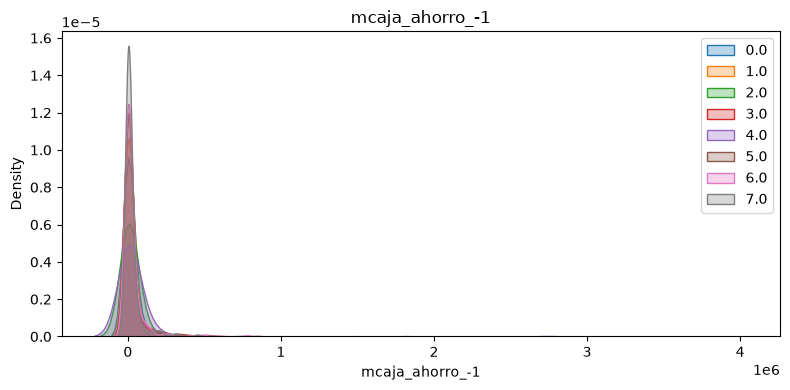

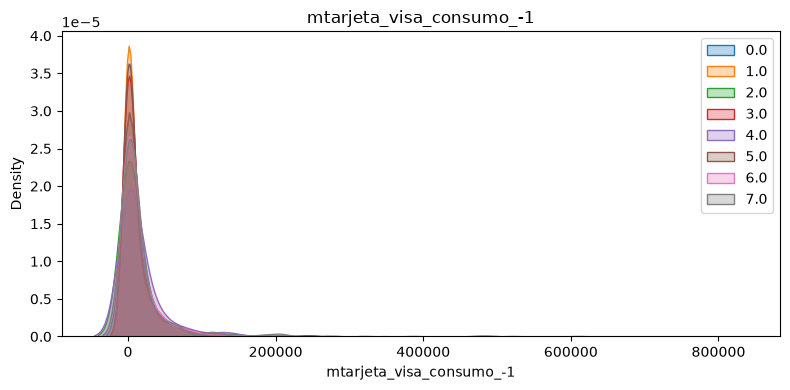

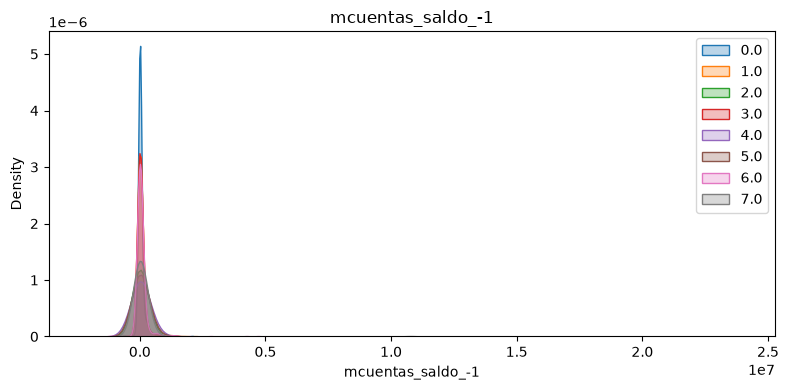

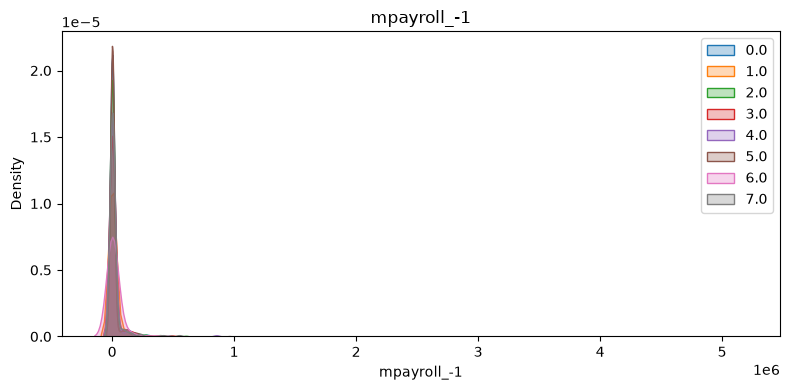

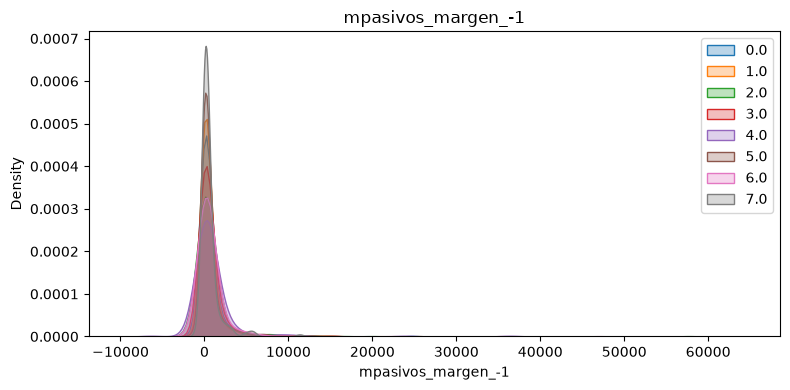

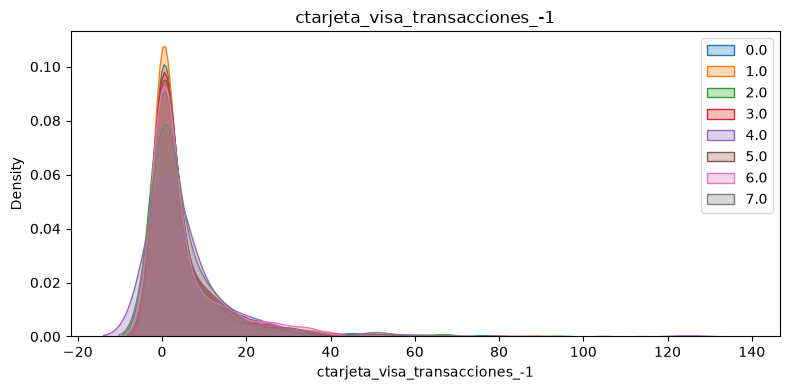

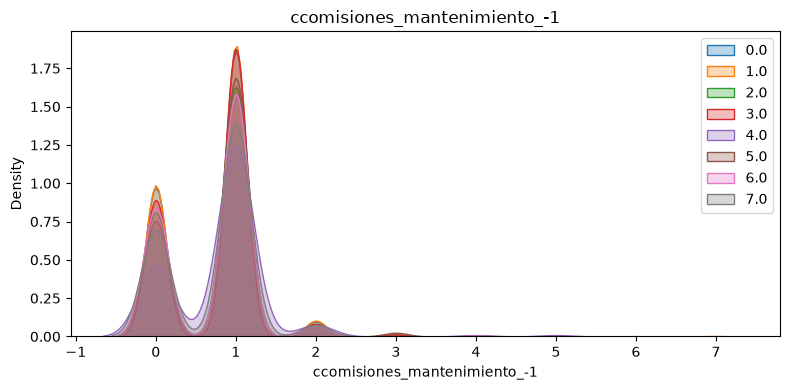

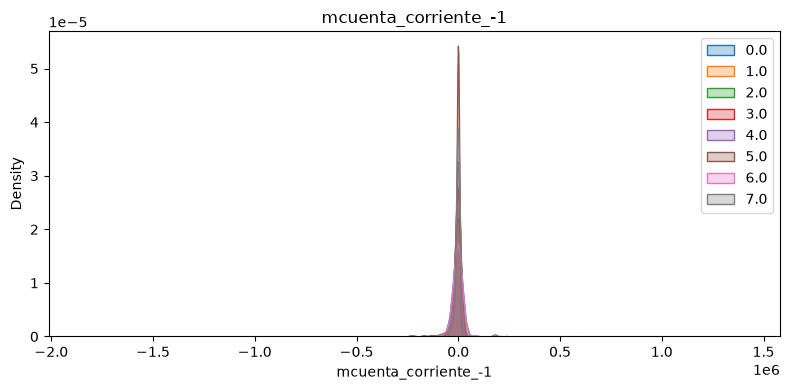

In [118]:
for feature in ranking_features[:10].index:
    fig, ax = plt.subplots(figsize=(8, 4))
    for cluster in df_clientes_2['k-means'].unique():
        subset = df_clientes_2.loc[
            df_clientes_2['k-means'] == cluster,
            feature
        ].dropna()

        sns.kdeplot(
            subset,
            ax=ax,
            label=cluster,
            fill=True,
            alpha=0.3
        )

    ax.set_title(feature)
    ax.legend()
    plt.tight_layout()
    plt.show()